In [16]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
import os
import random
import shutil
from PIL import Image
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
!pip install kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d shaunthesheep/microsoft-catsvsdogs-dataset
!unzip -q microsoft-catsvsdogs-dataset.zip -d /content

Dataset URL: https://www.kaggle.com/datasets/shaunthesheep/microsoft-catsvsdogs-dataset
License(s): other
microsoft-catsvsdogs-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
replace /content/MSR-LA - 3467.docx? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/PetImages/Cat/0.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


In [3]:
import os

path = "/content/PetImages"
print(os.listdir(path))

['Dog', 'Cat']


In [4]:
dog_count = len(os.listdir("/content/PetImages/Dog"))
cat_count = len(os.listdir("/content/PetImages/Cat"))

print("Dog images:", dog_count)
print("Cat images:", cat_count)

Dog images: 12501
Cat images: 12501


In [5]:
dataset_path = 'PetImages'
classes = ['Cat', 'Dog']

# 1. Identify and remove corrupted images
for cls in classes:
    path = os.path.join(dataset_path, cls)
    for img_name in os.listdir(path):
        img_path = os.path.join(path, img_name)
        try:
            img = Image.open(img_path)
            img.verify()
        except (IOError, SyntaxError):
            print(f'Removing (Corrupted/Invalid): {img_path}')
            os.remove(img_path)

Removing (Corrupted/Invalid): PetImages/Cat/666.jpg
Removing (Corrupted/Invalid): PetImages/Cat/Thumbs.db
Removing (Corrupted/Invalid): PetImages/Dog/11702.jpg
Removing (Corrupted/Invalid): PetImages/Dog/Thumbs.db


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


In [6]:
# 2. Balance the dataset (Fixed the variable order here)
cat_images = os.listdir(os.path.join(dataset_path, 'Cat'))
dog_images = os.listdir(os.path.join(dataset_path, 'Dog'))

# Calculate the minimum count first
min_count = min(len(cat_images), len(dog_images))

def balance_folder(folder_path, target_count):
    current_images = os.listdir(folder_path)
    if len(current_images) > target_count:
        to_remove = random.sample(current_images, len(current_images) - target_count)
        for img in to_remove:
            os.remove(os.path.join(folder_path, img))

# Balance both folders to the same size
balance_folder(os.path.join(dataset_path, 'Cat'), min_count)
balance_folder(os.path.join(dataset_path, 'Dog'), min_count)

print(f"Dataset successfully cleaned and balanced at {min_count} images per class.")

Dataset successfully cleaned and balanced at 12499 images per class.


In [8]:
dog_count = len(os.listdir("/content/PetImages/Dog"))
cat_count = len(os.listdir("/content/PetImages/Cat"))

print("Dog images:", dog_count)
print("Cat images:", cat_count)

Dog images: 12499
Cat images: 12499


In [9]:
output = "SplitData"
for split in ["train", "val", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(output, split, cls), exist_ok=True)

for cls in classes:
    files = os.listdir(os.path.join(dataset_path, cls))
    random.shuffle(files)

    train_split = int(len(files) * 0.8)
    val_split = int(len(files) * 0.1)

    # Copy files to respective split folders
    for f in files[:train_split]:
        shutil.copy(os.path.join(dataset_path, cls, f), os.path.join(output, "train", cls, f))
    for f in files[train_split : train_split + val_split]:
        shutil.copy(os.path.join(dataset_path, cls, f), os.path.join(output, "val", cls, f))
    for f in files[train_split + val_split :]:
        shutil.copy(os.path.join(dataset_path, cls, f), os.path.join(output, "test", cls, f))

print("Data splitting complete.")

Data splitting complete.


In [10]:
datagen = ImageDataGenerator(rescale=1./255) # Normalization

train_gen = datagen.flow_from_directory(
    'SplitData/train',
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary'
)

val_gen = datagen.flow_from_directory(
    'SplitData/val',
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary'
)

test_gen = datagen.flow_from_directory(
    'SplitData/test',
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    shuffle=False # Kept False for evaluation purposes
)

Found 19998 images belonging to 2 classes.
Found 2498 images belonging to 2 classes.
Found 2502 images belonging to 2 classes.


In [11]:
model = models.Sequential([
    # Input Layer and first Convolutional Block
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    layers.MaxPooling2D(2, 2),

    # Second Convolutional Block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    # Third Convolutional Block (New)
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    # Flatten and Dense Layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid') # Binary Output (Cat or Dog)
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = model.fit(train_gen, epochs=20, validation_data=val_gen)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 73ms/step - accuracy: 0.6884 - loss: 0.5878 - val_accuracy: 0.7446 - val_loss: 0.5101
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 64ms/step - accuracy: 0.7956 - loss: 0.4327 - val_accuracy: 0.7690 - val_loss: 0.4706
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 65ms/step - accuracy: 0.8363 - loss: 0.3599 - val_accuracy: 0.8082 - val_loss: 0.4294
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 64ms/step - accuracy: 0.8705 - loss: 0.2986 - val_accuracy: 0.8311 - val_loss: 0.3938
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 64ms/step - accuracy: 0.9121 - loss: 0.2108 - val_accuracy: 0.8347 - val_loss: 0.4169
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 64ms/step - accuracy: 0.9510 - loss: 0.1266 - val_accuracy: 0.8311 - val_loss: 0.5164
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 65ms/step - accuracy: 0.9763 - loss: 0.0712 - val_accuracy: 0.8287 - val_loss: 0.6904
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 65ms/step - accuracy: 0.9888 - loss: 0.0357 - 

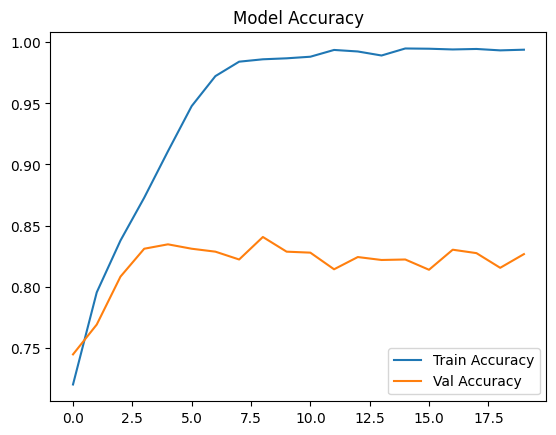

In [14]:
# Plotting Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.show()

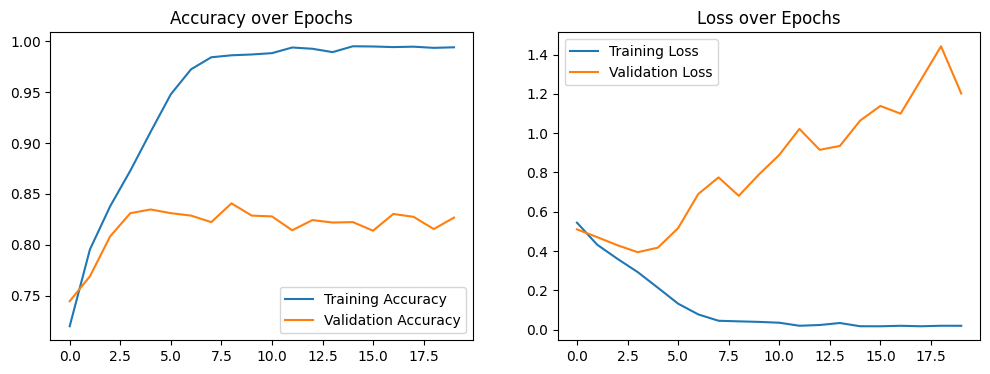

In [15]:
# Plot results
def plot_results(history):
    plt.figure(figsize=(12, 4))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy over Epochs')
    plt.legend()

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss over Epochs')
    plt.legend()
    plt.show()

plot_results(history)

In [17]:
import os

drive_path = '/content/drive/MyDrive/Cats&Dogs Model'

os.makedirs(drive_path, exist_ok=True)
print(f"Directory '{drive_path}' ensured to exist.")

Directory '/content/drive/MyDrive/Cats&Dogs Model' ensured to exist.


In [18]:
model_save_path = os.path.join(drive_path, 'cats_dogs_classifier.keras')
model.save(model_save_path)
print(f"Model saved successfully to {model_save_path}")

Model saved successfully to /content/drive/MyDrive/Cats&Dogs Model/cats_dogs_classifier.keras


In [19]:
import shutil
import os

# Compress the PetImages directory into a zip archive
# The base_name is 'PetImages', format is 'zip', root_dir is '/content', and base_dir is 'PetImages'
shutil.make_archive('PetImages', 'zip', '/content', 'PetImages')
print("Created PetImages.zip in /content")

# Define the source path of the zip file and the destination path in Google Drive
zip_source_path = '/content/PetImages.zip'
drive_destination_path = os.path.join(drive_path, 'PetImages.zip')

# Move the zip file to the Google Drive directory
shutil.move(zip_source_path, drive_destination_path)
print(f"Moved PetImages.zip to {drive_destination_path}")

Created PetImages.zip in /content
Moved PetImages.zip to /content/drive/MyDrive/Cats&Dogs Model/PetImages.zip


In [20]:
import shutil
import os

# Compress the SplitData directory into a zip archive
shutil.make_archive('SplitData', 'zip', '/content', 'SplitData')
print("Created SplitData.zip in /content")

# Define the source path of the zip file and the destination path in Google Drive
zip_source_path = '/content/SplitData.zip'
drive_destination_path = os.path.join(drive_path, 'SplitData.zip')

# Move the zip file to the Google Drive directory
shutil.move(zip_source_path, drive_destination_path)
print(f"Moved SplitData.zip to {drive_destination_path}")

Created SplitData.zip in /content
Moved SplitData.zip to /content/drive/MyDrive/Cats&Dogs Model/SplitData.zip
